In [1]:
import pandas as pd
import numpy as np
import plotly.express as px 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
f = '../data/temp.csv'
data = pd.read_csv(f, index_col=0, parse_dates=True)
data

,TEMP1,TEMP2,TEMP3,TEMP4
ts,,,,
2024-11-22 15:42:00.774,12.42,12.63,13.81,13.48
2024-11-22 15:42:03.505,12.37,12.57,13.81,13.46
2024-11-22 15:42:06.235,12.44,12.61,13.75,13.48
2024-11-22 15:42:08.965,12.46,12.59,13.79,13.45
2024-11-22 15:42:11.697,12.38,12.51,13.75,13.44
...,...,...,...,...
2024-11-22 17:08:46.549,50.30,49.92,50.47,51.13
2024-11-22 17:08:49.281,50.34,49.92,50.46,51.09
2024-11-22 17:08:52.010,50.29,49.89,50.46,51.13


In [3]:
fig = px.scatter(data, x=data.index,y=["TEMP1", "TEMP2", "TEMP3", "TEMP4"])
fig.update_layout(hovermode="x unified")
fig.show()

In [4]:
data["Tref"] = np.nan

data.loc[data.between_time("15:44:01", "15:52:31").index, "Tref"] = 10.
data.loc[data.between_time("16:02:06", "16:11:52").index, "Tref"] = 20.
data.loc[data.between_time("16:20:44", "16:28:58").index, "Tref"] = 30.
data.loc[data.between_time("16:39:23", "16:49:57").index, "Tref"] = 40.
data.loc[data.between_time("16:58:24", "17:08:25").index, "Tref"] = 50.

data_all = data.dropna(subset=["Tref"])

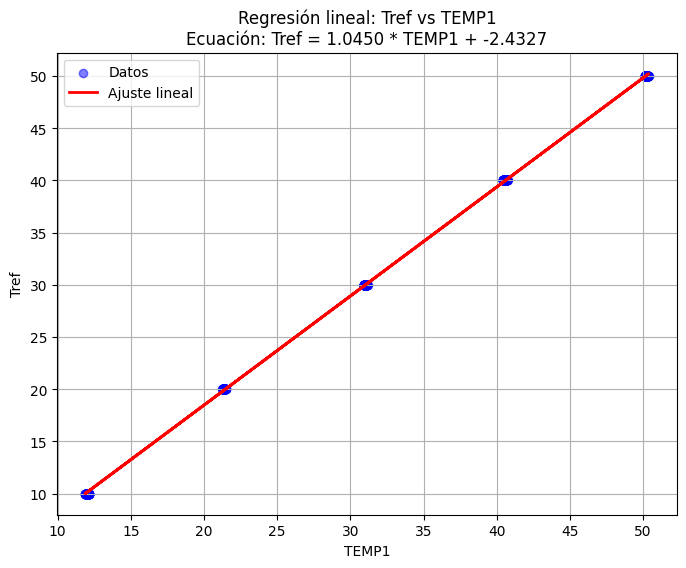

Para la columna TEMP1:
  Ecuación de calibración: Tref = 1.0450 * TEMP1 + -2.4327



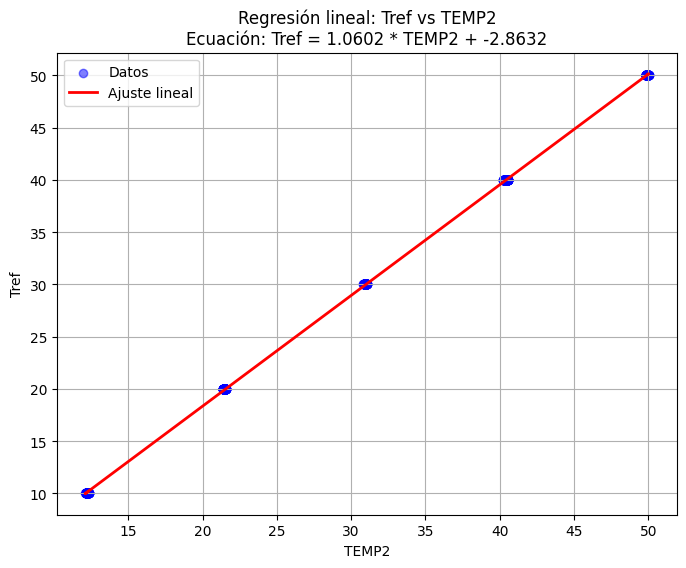

Para la columna TEMP2:
  Ecuación de calibración: Tref = 1.0602 * TEMP2 + -2.8632



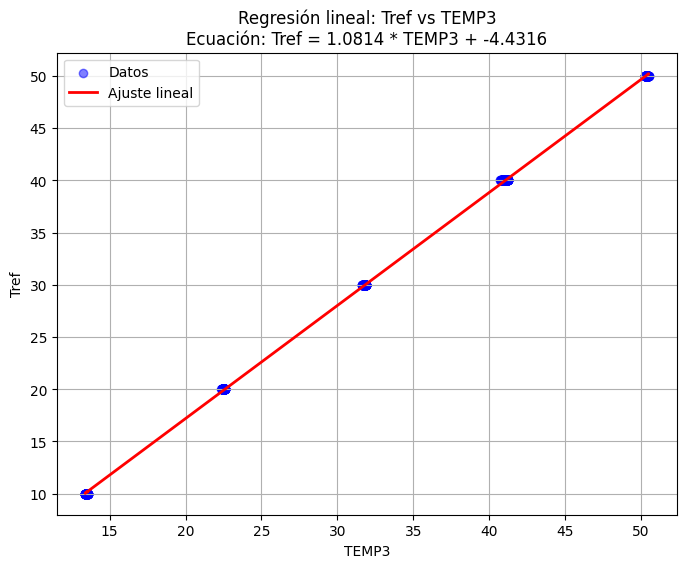

Para la columna TEMP3:
  Ecuación de calibración: Tref = 1.0814 * TEMP3 + -4.4316



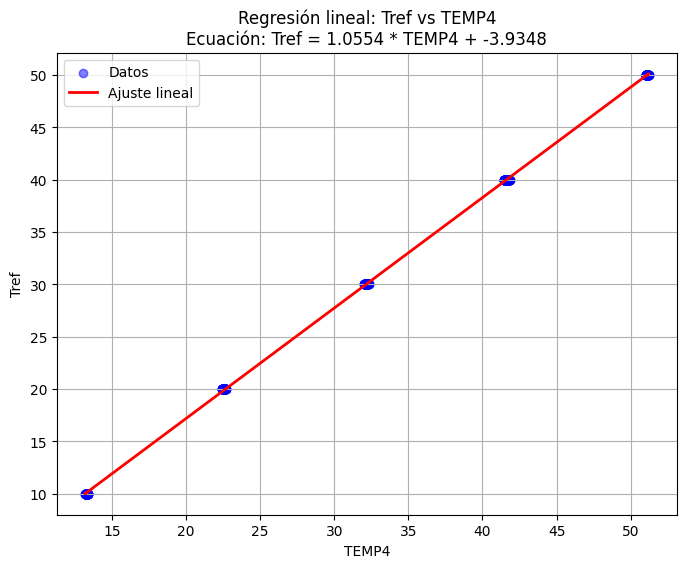

Para la columna TEMP4:
  Ecuación de calibración: Tref = 1.0554 * TEMP4 + -3.9348



In [5]:
columnas = [col for col in data_all.columns if col != 'Tref']

# Iteramos sobre cada columna para hacer la regresión y graficar
for col in columnas:

    temp = data_all[[col, 'Tref']].dropna()

    # Extraemos la variable independiente (x) y la dependiente (y)
    X = temp[col].values.reshape(-1, 1)  # x es la columna actual
    y = temp['Tref'].values             # y es la columna de referencia
    
    # Creamos y ajustamos el modelo de regresión lineal
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Coeficiente y ordenada al origen
    coef = modelo.coef_[0]
    intercepto = modelo.intercept_
    
    # Predicciones para la línea de regresión
    y_pred = modelo.predict(X)
    
    # Graficamos los datos y la línea de regresión
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', alpha=0.5, label='Datos')
    plt.plot(X, y_pred, color='red', linewidth=2, label='Ajuste lineal')
    plt.xlabel(col)
    plt.ylabel('Tref')
    plt.title(f'Regresión lineal: Tref vs {col}\nEcuación: Tref = {coef:.4f} * {col} + {intercepto:.4f}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Imprimimos la ecuación de calibración
    print(f'Para la columna {col}:')
    print(f'  Ecuación de calibración: Tref = {coef:.4f} * {col} + {intercepto:.4f}\n')